In [56]:
# Імпортуємо бібліотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils import resample
from sklearn.pipeline import Pipeline


In [57]:
# Завантаження даних
df = pd.read_csv("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv")

# Очищення даних: вибір важливих колонок та видалення порожніх значень
df = df[['reviews.text', 'reviews.rating']].dropna()

# Видаляємо нейтральні відгуки (рейтинг = 3)
df = df[df['reviews.rating'] != 3]

# Кодуємо класи: 1 — негативний, 0 — позитивний
df['label'] = df['reviews.rating'].apply(lambda x: 1 if x < 3 else 0)

# Виведення таблиці з балансом класів
print("Кількість позитивних та негативних відгуків:")
print(df['label'].value_counts())


Кількість позитивних та негативних відгуків:
label
0    4686
1     117
Name: count, dtype: int64


In [58]:
# Функція очистки тексту (видаляє пунктуацію, числа, перетворює на малий регістр)
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text

# Застосуємо функцію до текстових відгуків
df['clean_text'] = df['reviews.text'].apply(clean_text)

# Виведення кількох очищених відгуків
df_sample = df[['reviews.text', 'clean_text']].head(10)
print("\nПриклад очищених відгуків:")
df_sample



Приклад очищених відгуків:


,reviews.text,clean_text
1,This kindle is light and easy to use especiall...,this kindle is light and easy to use especiall...
2,Didnt know how much i'd use a kindle so went f...,didnt know how much id use a kindle so went fo...
3,I am 100 happy with my purchase. I caught it o...,i am happy with my purchase i caught it on sa...
4,Solid entry level Kindle. Great for kids. Gift...,solid entry level kindle great for kids gifted...
5,This make an excellent ebook reader. Don't exp...,this make an excellent ebook reader dont expec...
6,"I ordered this for my daughter, as I have the ...",i ordered this for my daughter as i have the b...
7,I bought my Kindle about 2 months ago and the ...,i bought my kindle about months ago and the b...
8,"amazon kindle is always the best ebook, upgrad...",amazon kindle is always the best ebook upgrade...
9,"It's beyond my expectation, and it can even sh...",its beyond my expectation and it can even show...
10,If you really want to have a good read on some...,if you really want to have a good read on some...


In [59]:
# Розділення на позитивні та негативні відгуки
df_minority = df[df['label'] == 1]  # Негативні відгуки
df_majority = df[df['label'] == 0]  # Позитивні відгуки

# Oversampling меншості (негативних відгуків)
df_minority_oversampled = resample(df_minority, 
                                   replace=True,    # Підвибірка з повторенням
                                   n_samples=len(df_majority),  # Рівна кількість
                                   random_state=42)  # Фіксація випадковості

# Об'єднуємо збільшений негативний клас з позитивним
df_balanced = pd.concat([df_majority, df_minority_oversampled])

# Перемішуємо дані для випадковості
df_balanced = df_balanced.sample(frac=1, random_state=42)

# Перевірка балансу класів після oversampling
print("\nБаланс класів після oversampling:")
print(df_balanced['label'].value_counts())



Баланс класів після oversampling:
label
1    4686
0    4686
Name: count, dtype: int64


In [60]:
# Розділяємо дані на тренувальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(df_balanced['clean_text'], df_balanced['label'], test_size=0.2, random_state=42)


In [61]:
# Створення pipeline з TF-IDF векторизацією та RandomForest
model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))  # Використовуємо RandomForestClassifier
])

# Навчання моделі
model.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('clf', RandomForestClassifier(random_state=42))])


Classification Report:

Accuracy: 1.0000


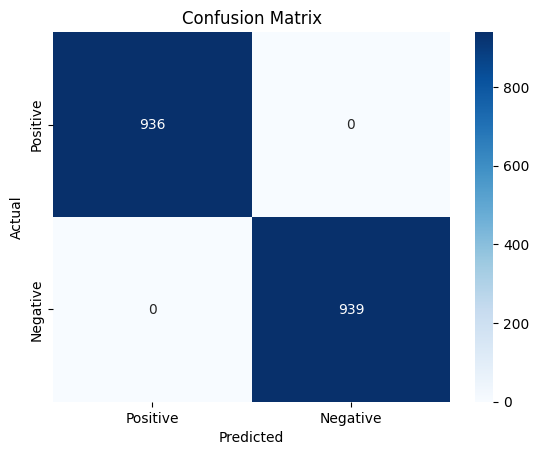

In [62]:
# Прогнозування на тестовому наборі
y_pred = model.predict(X_test)

# Оцінка моделі за допомогою classification report
classification_rep = classification_report(y_test, y_pred, output_dict=True)
print("\nClassification Report:")
df_report = pd.DataFrame(classification_rep).transpose()
df_report.style.background_gradient(cmap='Blues')  # Стиль для таблиці

# Точність моделі
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Виведення матриці сплутаних класів (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

# Візуалізація матриці сплутаних класів
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
